# **ENSADUL 2021: Guanajuato**
## Limpieza de Datos y Análisis Exploratorio (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('future.no_silent_downcasting', True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

---
## 1. Carga de datos

In [2]:
df = pd.read_csv('../data/raw/2021/ensadul2021_entrega_w1.csv', sep=';', low_memory=False)
df.shape

(1115, 704)

In [3]:
catalog = pd.read_excel('../data/raw/2021/ensadul2021_entrega_w1.Catlogo.xlsx',
                        sheet_name='Variables', skiprows=16)
print(catalog.columns.tolist())
catalog.head()

['Variable', 'Posición', 'Etiqueta', 'Nivel de medición', 'Ancho de columna']


,Variable,Posición,Etiqueta,Nivel de medición,Ancho de columna
0,FOLIO_I,1.0,Folio,Nominal,15.0
1,FOLIO_INT,2.0,Folio de integrante,Nominal,18.0
2,maquina,3.0,Maquina,Nominal,26.0
3,hora_ini_1,4.0,Hora de Inicio 1,Nominal,26.0
4,fecha_ini_1,5.0,Fecha de Inicio 1,Nominal,26.0


In [4]:
# Renombrar solo etiquetas ÚNICAS — las duplicadas conservan su código original
# (2021 tiene 56 etiquetas duplicadas para sub-preguntas de la misma sección)
label_counts = Counter(catalog['Etiqueta'].dropna().tolist())
col_mapping = {
    row['Variable']: row['Etiqueta']
    for _, row in catalog.iterrows()
    if pd.notna(row['Variable']) and pd.notna(row['Etiqueta'])
    and label_counts[row['Etiqueta']] == 1
}
df.rename(columns=col_mapping, inplace=True)
df_original = df.copy()
print(f'Columnas renombradas: {len(col_mapping)}')
print(f'Columnas con código original (etiqueta duplicada): {len(df.columns) - len(col_mapping)}')

Columnas renombradas: 464
Columnas con código original (etiqueta duplicada): 240


---
## 2. Limpieza de datos

### 2.1 Reemplazar espacios en blanco y strings vacíos por NaN

In [5]:
df = df.replace(' ', np.nan).replace('', np.nan)
print(f'Filas: {len(df)} | Columnas: {len(df.columns)}')

Filas: 1115 | Columnas: 704


### 2.2 Eliminar columnas con >70% de valores nulos

In [6]:
threshold = int(len(df) * 0.30)
df = df.dropna(thresh=threshold, axis=1)
print(f'Columnas eliminadas: {len(df_original.columns) - len(df.columns)}')
print(f'Columnas restantes:  {len(df.columns)}')

Columnas eliminadas: 540
Columnas restantes:  164


### 2.3 Eliminar columnas con menos de 800 valores no nulos

In [7]:
cs = df.count()
to_drop = cs[cs < 800].index.tolist()
df = df.drop(columns=to_drop)
print(f'Columnas eliminadas: {len(to_drop)}')
print(f'Columnas restantes:  {len(df.columns)}')

Columnas eliminadas: 37
Columnas restantes:  127


### 2.4 Eliminar columnas NOTA

In [8]:
nota = [c for c in df.columns if 'NOTA' in str(c)]
df = df.drop(columns=nota)
print(f'Columnas NOTA eliminadas: {len(nota)}')

Columnas NOTA eliminadas: 22


### 2.5 Eliminar columnas constantes y administrativas

In [9]:
# Constantes
nu = df.nunique(dropna=True)
constantes = nu[nu <= 1].index.tolist()
df = df.drop(columns=constantes)
print(f'Constantes eliminadas: {len(constantes)}')

# Administrativas / logísticas
admin_cols = [
    'Folio','Folio de integrante','Maquina',
    'Hora de Inicio 1','Fecha de Inicio 1','Hora termino 1','Fecha termino 1',
    'Hora de Inicio','Fecha de inicio','Hora de termino','Fecha de Termino',
    'Duración de la Entrevista 1','Resultado de entrevista 1',
    'Duración de la Entrevista 2','Resultado de entrevista 2',
    'Duración de la Entrevista 3','Resultado de entrevista 3',
    'Duración de la Entrevista 4','Resultado de entrevista 4',
    'Duración de la Entrevista','Resultado de Entrevista',
    'Region o zona de trabajo','Entidad','DESC_ENT',
    'Fecha de Nacimiento','AGEB','MZA','Vivienda','hogar','Localidad',
]
admin_cols = [c for c in admin_cols if c in df.columns]
df = df.drop(columns=admin_cols)
print(f'Administrativas eliminadas: {len(admin_cols)}')
print(f'Columnas restantes: {len(df.columns)}')

Constantes eliminadas: 4
Administrativas eliminadas: 26
Columnas restantes: 75


### 2.6 Corregir tipos de datos

In [10]:
# Convertir object → numérico donde corresponda
obj_cols = df.select_dtypes(include='object').columns.tolist()
converted_cols = []
for col in obj_cols:
    series = df[col]
    if isinstance(series, pd.DataFrame):
        continue
    nv = series.notna().sum()
    if nv == 0:
        continue
    conv = pd.to_numeric(series, errors='coerce')
    if conv.notna().sum() / nv > 0.7:
        df[col] = conv
        converted_cols.append(col)

# Ponderador (coma decimal → punto)
if 'Ponderador' in df.columns:
    df['Ponderador'] = pd.to_numeric(
        df['Ponderador'].astype(str).str.replace(',', '.', regex=False), errors='coerce')

print(f'Columnas convertidas a numérico: {len(converted_cols)}')
print(f'Tipos finales: {df.dtypes.value_counts().to_dict()}')

Columnas convertidas a numérico: 51
Tipos finales: {dtype('float64'): 52, dtype('int64'): 21, dtype('O'): 2}


### 2.7 Tratar valor centinela 999 en peso habitual

In [11]:
col_peso = '¿Cuál es su peso habitual sin ropa y zapatos?'
if col_peso in df.columns:
    n_999 = (df[col_peso] == 999).sum()
    df[col_peso] = df[col_peso].replace(999, np.nan)
    print(f'Valores 999 reemplazados por NaN en peso habitual: {n_999}')
    print(f'Nulos en peso habitual ahora: {df[col_peso].isna().sum()}')

Valores 999 reemplazados por NaN en peso habitual: 75
Nulos en peso habitual ahora: 76


### 2.8 Verificar duplicados

In [12]:
print(f'Filas duplicadas: {df.duplicated().sum()}')
print(f'Shape del dataset: {df.shape}')

Filas duplicadas: 0
Shape del dataset: (1115, 75)


### 2.9 Revisar nulos restantes

In [13]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print(f'Columnas con valores nulos: {len(null_pct)}')
print()
print(null_pct.round(1).to_string())

Columnas con valores nulos: 51

A1411 Entonces, ¿el tiempo que pasó usted caminando, solo para trasladarse de un    25.0
A1410M Generalmente, ¿Cuánto tiempo camina usted en uno de esos días? MINUTOS       25.0
A1410H Generalmente, ¿Cuánto tiempo camina usted en uno de esos días? HORAS         25.0
¿Me puede mostrar su Cartilla Nacional de Salud (Hombre o Mujer de 20 a 59 años)    23.3
A1001H h) detección de hipertensión?                                                21.3
A1305 En el pasado¿ha fumado productos del tabaco…                                  18.0
A1001I i) detección de colesterol o triglicéridos altos (examen de sangre)?         17.8
A1001G g) detección de diabetes?                                                    11.0
¿Su HERMANO(A)  tuvo un infarto?                                                     9.1
¿Su HERMANO(A) tiene o tuvo hipertensión o presión alta?                             9.1
¿Su HERMANO(A) tiene o tuvo diabetes o azúcar alta en la sangre?              

### 2.10 Análisis e imputación de valores nulos

A continuación se analiza cada grupo de columnas con nulos, se justifica la estrategia y se aplica.

#### Variables 1–3/10 — Actividad física: duración de caminata

In [14]:
col_a1409  = 'A1409 Durante los últimos 7 días, ¿Cuántos días usted caminó por lo menos 10 min'
col_a1410h = 'A1410H Generalmente, ¿Cuánto tiempo camina usted en uno de esos días? HORAS'
col_a1410m = 'A1410M Generalmente, ¿Cuánto tiempo camina usted en uno de esos días? MINUTOS'
col_a1411  = 'A1411 Entonces, ¿el tiempo que pasó usted caminando, solo para trasladarse de un'

print('A1409 (días caminados) valores:', df[col_a1409].value_counts(dropna=False).head(6).to_dict()
      if col_a1409 in df.columns else 'no presente')
for c in [col_a1410h, col_a1410m, col_a1411]:
    if c in df.columns:
        print(f'{c[-40:]}: {df[c].isna().sum()} nulos')

A1409 (días caminados) valores: {7: 536, 0: 273, 2: 71, 3: 70, 5: 53, 1: 45}
 camina usted en uno de esos días? HORAS: 279 nulos
amina usted en uno de esos días? MINUTOS: 279 nulos
d caminando, solo para trasladarse de un: 279 nulos


In [15]:
# ── Análisis ──────────────────────────────────────────────────────────────
# Los nulos en A1410H, A1410M y A1411 corresponden exactamente a personas que
# indicaron A1409=0 (ningún día caminaron al menos 10 minutos en la última semana).
# Son nulos ESTRUCTURALES por lógica de salto.
#
# Estrategia:
#   A1410H y A1410M → 0 (cero horas/minutos: no caminaron)
#   A1411            → moda = 1 (la pregunta no aplica; se asigna la respuesta más común)

for col in [col_a1410h, col_a1410m]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

if col_a1411 in df.columns:
    moda_1411 = int(df[col_a1411].mode()[0])
    df[col_a1411] = df[col_a1411].fillna(moda_1411)

print('Nulos restantes en columnas de caminata:',
      {c: int(df[c].isna().sum()) for c in [col_a1410h, col_a1410m, col_a1411] if c in df.columns})

Nulos restantes en columnas de caminata: {'A1410H Generalmente, ¿Cuánto tiempo camina usted en uno de esos días? HORAS': 0, 'A1410M Generalmente, ¿Cuánto tiempo camina usted en uno de esos días? MINUTOS': 0, 'A1411 Entonces, ¿el tiempo que pasó usted caminando, solo para trasladarse de un': 0}


#### Variable 4/10 — Cartilla Nacional de Salud

In [16]:
col_cart = '¿Me puede mostrar su Cartilla Nacional de Salud (Hombre o Mujer de 20 a 59 años)'
if col_cart in df.columns:
    print('Distribución:', df[col_cart].value_counts(dropna=False).to_dict())
    # Valores: 1=Sí completa, 2=Incompleta, 3=Sin registros, 4=No la tiene, 5=No aplica (>60)
    # Nulos: personas que no la presentaron y no aplica categoría de "no la tiene"
    # Estrategia: moda = 4 (No tiene cartilla)

Distribución: {4.0: 393, 3.0: 350, nan: 260, 1.0: 86, 5.0: 26}


In [17]:
if col_cart in df.columns:
    moda_cart = int(df[col_cart].mode()[0])
    df[col_cart] = df[col_cart].fillna(moda_cart)
    print(f'Imputado con moda = {moda_cart}')
    print(f'Nulos restantes: {df[col_cart].isna().sum()}')

Imputado con moda = 4
Nulos restantes: 0


#### Variable 5/10 — `A1001H` Detección de hipertensión

In [18]:
col_h = 'A1001H h) detección de hipertensión?'
col_f = 'A1001F f) detección de sobrepeso u obesidad?'
if col_h in df.columns:
    print('A1001H distribución:', df[col_h].value_counts(dropna=False).to_dict())
    if col_f in df.columns:
        print('A1001H nulls × A1001F:', df.loc[df[col_h].isna(), col_f].value_counts(dropna=False).to_dict())

A1001H distribución: {2.0: 797, nan: 238, 1.0: 80}
A1001H nulls × A1001F: {2.0: 217, 1.0: 20, nan: 1}


In [19]:
# ── Análisis ──────────────────────────────────────────────────────────────
# Skip logic: personas que no asistieron a ningún servicio de detección también
# omiten A1001H. El 90%+ de respuestas válidas = 2 (No).
# Estrategia: moda = 2 (No).

if col_h in df.columns:
    moda_h = int(df[col_h].mode()[0])
    df[col_h] = df[col_h].fillna(moda_h)
    print(f'A1001H imputado con moda = {moda_h} (No) | nulos: {df[col_h].isna().sum()}')

A1001H imputado con moda = 2 (No) | nulos: 0


#### Variable 6/10 — `A1305` ¿Ha fumado en el pasado?

In [20]:
col_pasado = 'A1305 En el pasado¿ha fumado productos del tabaco…'
col_actual  = 'A1301 Actualmente, ¿fuma tabaco…'
if col_pasado in df.columns and col_actual in df.columns:
    print('A1305 distribución:', df[col_pasado].value_counts(dropna=False).to_dict())
    print('A1305 nulls × A1301:', df.loc[df[col_pasado].isna(), col_actual].value_counts(dropna=False).to_dict())

A1305 distribución: {3.0: 707, nan: 201, 2.0: 140, 1.0: 60, 9.0: 7}
A1305 nulls × A1301: {1: 118, 2: 73, 9: 10}


In [21]:
# ── Análisis ──────────────────────────────────────────────────────────────
# Idéntico al patrón de 2022: todos los nulos son fumadores actuales (A1301=1,2).
# Estrategia: categoría 0 = "Actualmente fuma".

if col_pasado in df.columns:
    df[col_pasado] = df[col_pasado].fillna(0)
    label_map = {0:'Actualmente fuma',1:'Fumaba (diario)',2:'Fumaba (ocas.)',3:'Nunca fumó',9:'No sabe'}
    print('Distribución final:', df[col_pasado].map(label_map).value_counts().to_dict())
    print(f'Nulos restantes: {df[col_pasado].isna().sum()}')

Distribución final: {'Nunca fumó': 707, 'Actualmente fuma': 201, 'Fumaba (ocas.)': 140, 'Fumaba (diario)': 60, 'No sabe': 7}
Nulos restantes: 0


#### Variable 7/10 — `A1001I` Detección de colesterol/triglicéridos

In [22]:
col_i = 'A1001I i) detección de colesterol o triglicéridos altos (examen de sangre)?'
if col_i in df.columns:
    print('Distribución:', df[col_i].value_counts(dropna=False).to_dict())
    # Skip logic igual a A1001G/H. Moda = 2 (No).
    moda_i = int(df[col_i].mode()[0])
    df[col_i] = df[col_i].fillna(moda_i)
    print(f'Imputado con moda = {moda_i} (No) | nulos: {df[col_i].isna().sum()}')

Distribución: {2.0: 862, nan: 199, 1.0: 54}
Imputado con moda = 2 (No) | nulos: 0


#### Variable 8/10 — `A1001G` Detección de diabetes

In [23]:
col_g = 'A1001G g) detección de diabetes?'
if col_g in df.columns:
    print('Distribución:', df[col_g].value_counts(dropna=False).to_dict())
    if col_f in df.columns:
        print('A1001G nulls × A1001F:', df.loc[df[col_g].isna(), col_f].value_counts(dropna=False).to_dict())
    moda_g = int(df[col_g].mode()[0])
    df[col_g] = df[col_g].fillna(moda_g)
    print(f'Imputado con moda = {moda_g} (No) | nulos: {df[col_g].isna().sum()}')

Distribución: {2.0: 864, 1.0: 128, nan: 123}
A1001G nulls × A1001F: {2.0: 113, 1.0: 9, nan: 1}
Imputado con moda = 2 (No) | nulos: 0


#### Variables 9/10 — Antecedentes hermano(a) × 4 + Tiene hermanos

In [24]:
col_href = 'Tiene/Tuvo usted hermanos(as)'
herm_cols = [
    '¿Su HERMANO(A) tiene o tuvo diabetes o azúcar alta en la sangre?',
    '¿Su HERMANO(A) tiene o tuvo hipertensión o presión alta?',
    '¿Su HERMANO(A)  tuvo un infarto?',
    '¿Su HERMANO(A) tuvo valores altos de colesterol y/o triglicéridos?',
]
herm_cols = [c for c in herm_cols if c in df.columns]

print('Nulos por columna hermano:', {c[-25:]: int(df[c].isna().sum()) for c in herm_cols})
if col_href in df.columns:
    print('Tiene/Tuvo hermanos nulls:', int(df[col_href].isna().sum()))
    print('Tiene/Tuvo hermanos × nulo en hermano col:',
          df.loc[df[herm_cols[0]].isna(), col_href].value_counts(dropna=False).to_dict())

Nulos por columna hermano: {'azúcar alta en la sangre?': 101, 'ertensión o presión alta?': 101, 'MANO(A)  tuvo un infarto?': 101, 'sterol y/o triglicéridos?': 101}
Tiene/Tuvo hermanos nulls: 1
Tiene/Tuvo hermanos × nulo en hermano col: {2.0: 100, nan: 1}


In [25]:
# ── Análisis ──────────────────────────────────────────────────────────────
# 100 nulos vienen de personas sin hermanos (Tiene/Tuvo=2).
# 1 nulo adicional viene del único nulo en Tiene/Tuvo hermanos.
# Estrategia: Tiene/Tuvo → moda = 1. Columnas hermanos → 2 (No).

if col_href in df.columns:
    moda_href = int(df[col_href].mode()[0])
    df[col_href] = df[col_href].fillna(moda_href)
    print(f'Tiene hermanos: imputado con moda = {moda_href} | nulos: {df[col_href].isna().sum()}')

for col in herm_cols:
    df[col] = df[col].fillna(2)
    print(f'{col[-35:]}: nulos restantes = {df[col].isna().sum()}')

Tiene hermanos: imputado con moda = 1 | nulos: 0
iabetes o azúcar alta en la sangre?: nulos restantes = 0
o tuvo hipertensión o presión alta?: nulos restantes = 0
¿Su HERMANO(A)  tuvo un infarto?: nulos restantes = 0
os de colesterol y/o triglicéridos?: nulos restantes = 0


#### Variable 10/10 — Unidad primaria de muestreo + nulos residuales (0.1%)

In [26]:
# UPM: variable administrativa → eliminar
if 'Unidad primaria de muestreo' in df.columns:
    df = df.drop(columns=['Unidad primaria de muestreo'])
    print("'Unidad primaria de muestreo' eliminada (variable administrativa)")

# Peso habitual: mediana para los 76 nulos restantes (1 original + 75 valores 999 reemplazados)
col_peso = '¿Cuál es su peso habitual sin ropa y zapatos?'
if col_peso in df.columns:
    mediana_peso = df[col_peso].median()
    df[col_peso] = df[col_peso].fillna(mediana_peso)
    print(f'Peso habitual: imputado con mediana = {mediana_peso:.1f} kg | nulos: {df[col_peso].isna().sum()}')

# Resto de columnas con 1 nulo (0.1%) → moda
null_residual = df.columns[df.isnull().sum() > 0].tolist()
for col in null_residual:
    moda = df[col].mode()
    if len(moda) > 0:
        df[col] = df[col].fillna(moda[0])

print(f'\nNulos residuales imputados con moda: {len(null_residual)} columnas')

'Unidad primaria de muestreo' eliminada (variable administrativa)
Peso habitual: imputado con mediana = 70.0 kg | nulos: 0

Nulos residuales imputados con moda: 36 columnas


#### Verificación final

In [27]:
total_nulos = df.isnull().sum().sum()
print(f'Total de valores nulos en el dataset: {total_nulos}')
print(f'Shape final: {df.shape}')
if total_nulos == 0:
    print('\n✓ El dataset está completamente limpio — sin valores nulos.')
else:
    print('\nColumnas con nulos restantes:')
    print(df.isnull().sum()[df.isnull().sum() > 0])

Total de valores nulos en el dataset: 0
Shape final: (1115, 74)

✓ El dataset está completamente limpio — sin valores nulos.


### 2.11 Crear variables derivadas

In [28]:
# Grupos etarios
bins   = [20, 30, 40, 50, 60, 70, 80, 100]
labels = ['20-29','30-39','40-49','50-59','60-69','70-79','80+']
df['Grupo etario'] = pd.cut(df['Edad del Seleccionado'], bins=bins, labels=labels, right=False)

# Sexo como etiqueta
df['Sexo'] = df['Sexo del Seleccionado'].map({1:'Hombre', 2:'Mujer'})

# Urbanidad
df['Urbanidad'] = df['Estrato urbanidad/ruralidad'].map({1:'Rural',2:'Semi-urbano',3:'Urbano'})

# Municipio limpio
if 'DESC_MUN' in df.columns:
    df['Municipio'] = df['DESC_MUN'].str.replace(r'^\d+\s+', '', regex=True)

# Score depresión (CES-D 7 ítems)
dep_neg = [
    'Durante la última semana...¿Sentía como si no pudiera quitarse de encima la tris',
    'Durante la última semana...¿le costaba concentrarse en lo que estaba haciendo?',
    'Durante la última semana...¿se sintió deprimido/a?',
    'Durante la última semana...¿le parecía que todo lo que hacía era un esfuerzo?',
    'Durante la última semana...¿no durmió bien?',
    'Durante la última semana...¿se sintió triste?',
]
dep_pos = ['Durante la última semana...¿disfruto de la vida?']
dep_neg = [c for c in dep_neg if c in df.columns]
dep_pos = [c for c in dep_pos if c in df.columns]

dep_score = df[dep_neg].sum(axis=1)
for c in dep_pos:
    dep_score += (5 - df[c])
df['Score depresión'] = dep_score

# Minutos totales de caminata semanal
col_h = 'A1410H Generalmente, ¿Cuánto tiempo camina usted en uno de esos días? HORAS'
col_m = 'A1410M Generalmente, ¿Cuánto tiempo camina usted en uno de esos días? MINUTOS'
col_d = 'A1409 Durante los últimos 7 días, ¿Cuántos días usted caminó por lo menos 10 min'
if all(c in df.columns for c in [col_h, col_m, col_d]):
    df['Minutos caminata/semana'] = (df[col_h]*60 + df[col_m]) * df[col_d]

print(f'\nDataset listo para análisis: {df.shape}')


Dataset listo para análisis: (1115, 79)


### 2.12 Resumen del dataset limpio

In [29]:
display(df.describe(include='all').T[['count','unique','top','freq','mean','std','min','max']])

,count,unique,top,freq,mean,std,min,max
Municipio,1115,24,LEÓN,276,NaN,NaN,NaN,NaN
DESC_MUN,1115,24,020 LEÓN,276,NaN,NaN,NaN,NaN
DESC_LOC,1115,42,0001 LEÓN DE LOS ALDAMA,276,NaN,NaN,NaN,NaN
Edad del Seleccionado,1115.0,NaN,NaN,NaN,46.219731,17.375181,20.0,96.0
Sexo del Seleccionado,1115.0,NaN,NaN,NaN,1.635874,0.4814,1.0,2.0
ASEXO ¿Cuál es el sexo de (NOMBRE) ?,1115.0,NaN,NaN,NaN,1.636771,0.481146,1.0,2.0
AEDAD ¿Cuántos años cumplidos tiene actualmente (NOMBRE) ?,1115.0,NaN,NaN,NaN,46.243049,17.382722,20.0,96.0
¿Alguna vez le ha dicho un médico/dietista/nutriólogo que tiene o tuvo obesidad?,1115.0,NaN,NaN,NaN,1.780269,0.41425,1.0,2.0
"Ahora le voy a mostrar unas figuras corporales, por favor, dígame qué figura sie",1115.0,NaN,NaN,NaN,4.778475,1.90112,0.0,9.0
¿Cuál es su peso habitual sin ropa y zapatos?,1115.0,NaN,NaN,NaN,71.504036,14.947086,40.0,178.0


In [30]:
# Exportar dataset limpio
clean_path = '../data/processed/ensadul2021_GTO_clean.csv'
df.to_csv(clean_path, index=False, encoding='utf-8-sig')
print(f'Dataset limpio exportado → {clean_path}')
print(f'Shape: {df.shape}')

Dataset limpio exportado → ../data/processed/ensadul2021_GTO_clean.csv
Shape: (1115, 79)


---
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Demografía general

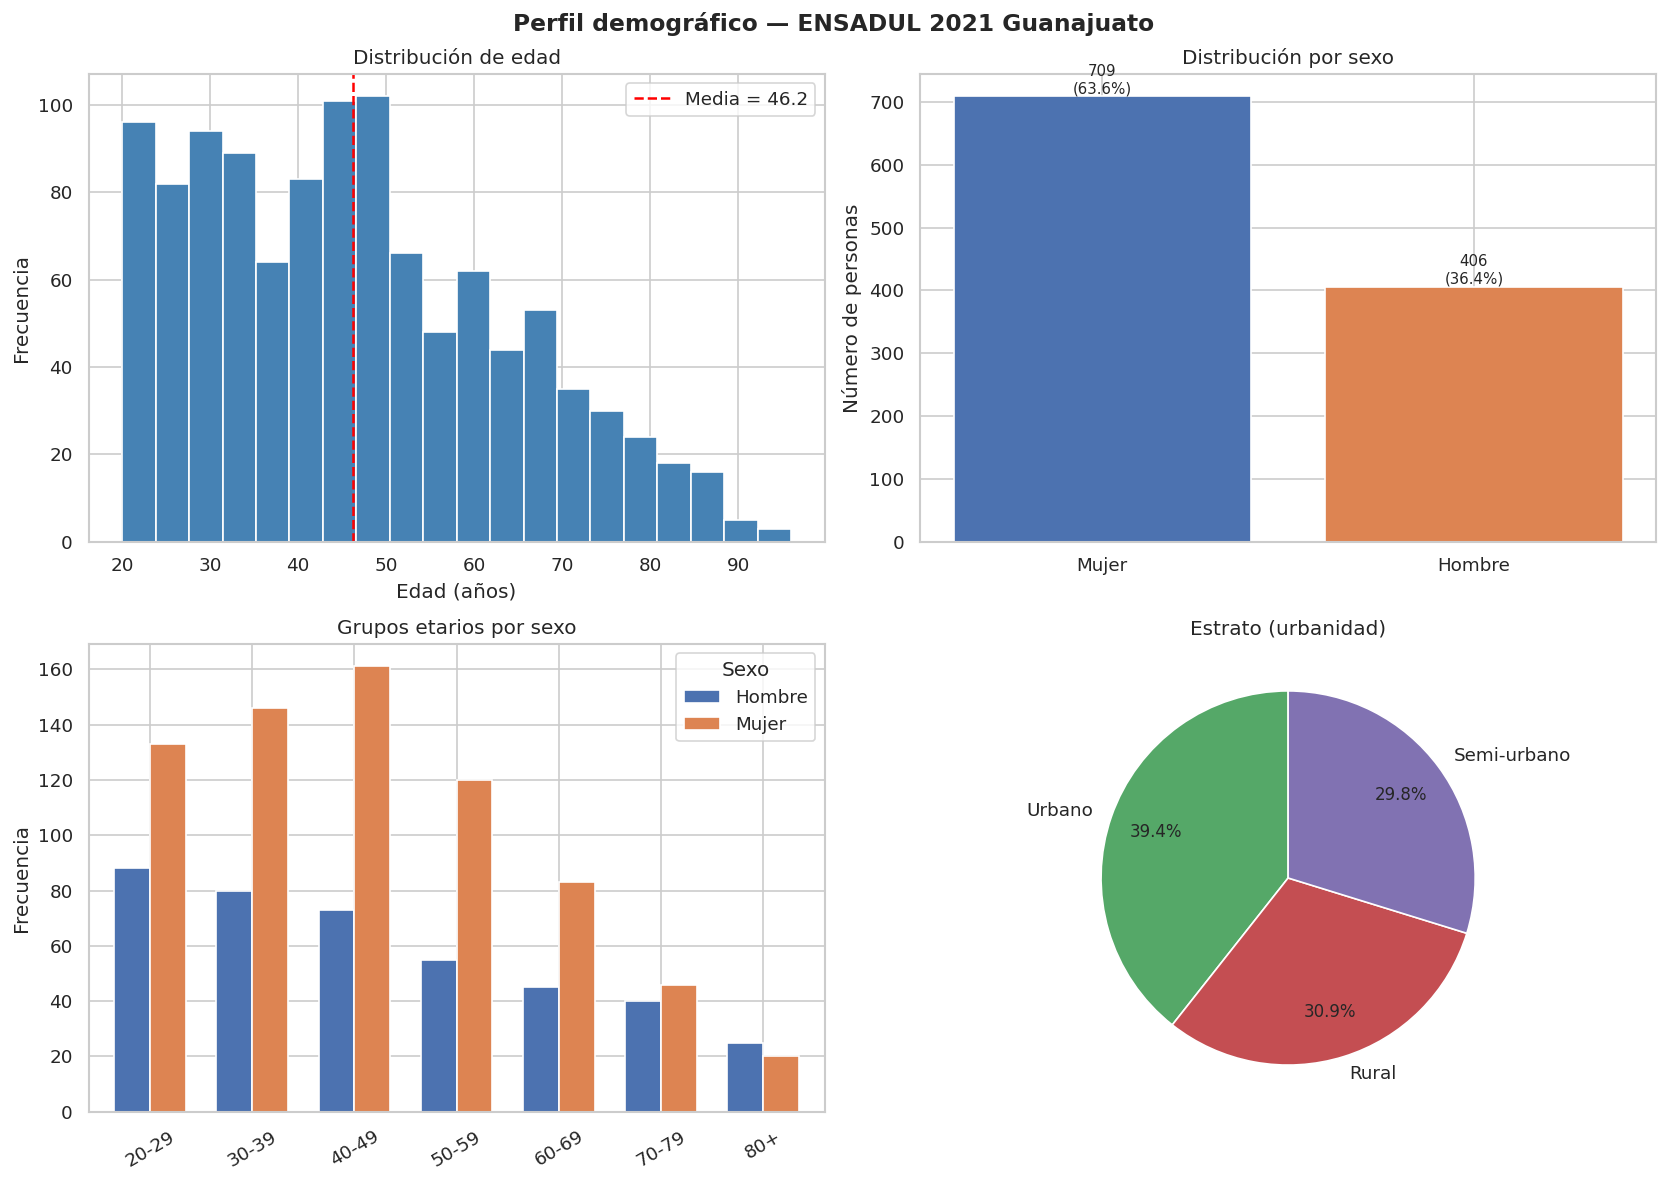

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perfil demográfico — ENSADUL 2021 Guanajuato', fontsize=14, fontweight='bold')

ax = axes[0,0]
ax.hist(df['Edad del Seleccionado'].dropna(), bins=20, color='steelblue', edgecolor='white')
ax.set_title('Distribución de edad'); ax.set_xlabel('Edad (años)'); ax.set_ylabel('Frecuencia')
ax.axvline(df['Edad del Seleccionado'].mean(), color='red', linestyle='--',
           label=f'Media = {df["Edad del Seleccionado"].mean():.1f}')
ax.legend()

ax = axes[0,1]
sex_counts = df['Sexo'].value_counts()
bars = ax.bar(sex_counts.index, sex_counts.values, color=['#4C72B0','#DD8452'], edgecolor='white')
ax.set_title('Distribución por sexo'); ax.set_ylabel('Número de personas')
for bar, val in zip(bars, sex_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

ax = axes[1,0]
cross = df.groupby(['Grupo etario','Sexo'], observed=True).size().unstack(fill_value=0)
cross.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'], edgecolor='white', width=0.7)
ax.set_title('Grupos etarios por sexo'); ax.set_xlabel(''); ax.set_ylabel('Frecuencia')
ax.legend(title='Sexo'); ax.tick_params(axis='x', rotation=30)

ax = axes[1,1]
urb = df['Urbanidad'].value_counts()
ax.pie(urb.values, labels=urb.index, autopct='%1.1f%%',
       colors=['#55A868','#C44E52','#8172B2'], startangle=90, pctdistance=0.75)
ax.set_title('Estrato (urbanidad)')

plt.tight_layout()
plt.savefig('../outputs/figures/2021/eda_demografia.png', bbox_inches='tight')
plt.show()

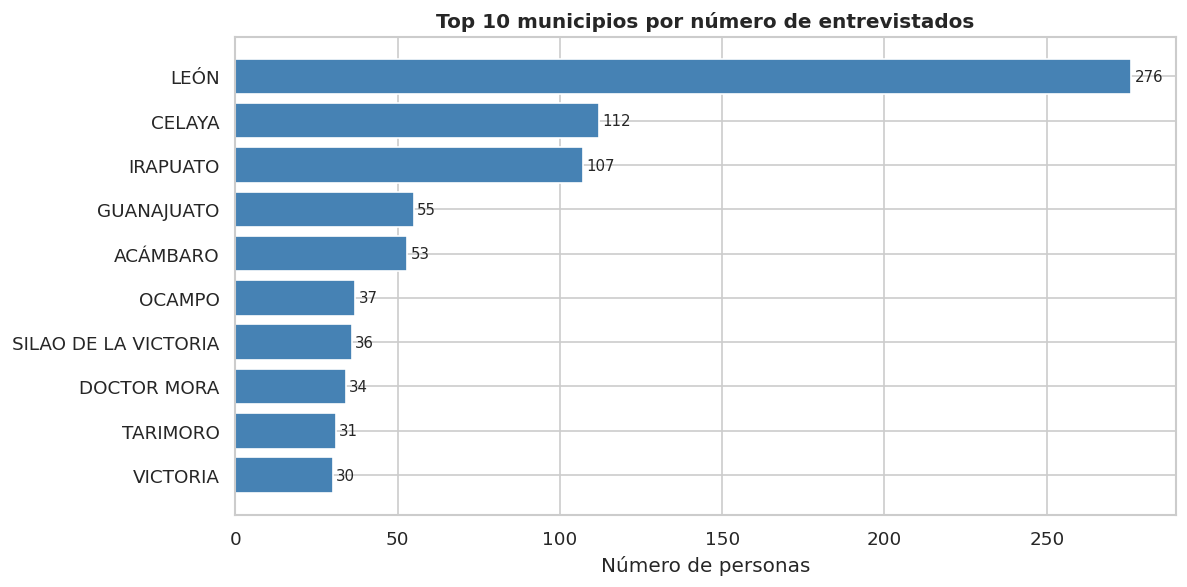

In [32]:
if 'Municipio' in df.columns:
    mun_top = df['Municipio'].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(10,5))
    bars = ax.barh(mun_top.index[::-1], mun_top.values[::-1], color='steelblue', edgecolor='white')
    ax.set_title('Top 10 municipios por número de entrevistados', fontweight='bold')
    ax.set_xlabel('Número de personas')
    for bar, val in zip(bars, mun_top.values[::-1]):
        ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2, str(val), va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../outputs/figures/2021/eda_municipios.png', bbox_inches='tight')
    plt.show()

### 3.2 Prevalencia de enfermedades crónicas

In [33]:
enf_cols = {
    'Diabetes':              '¿Algún médico le ha dicho que tiene diabetes (o alta el azúcar en la sangre)?',
    'Hipertensión':          '¿Algún médico le ha dicho que tiene la presión alta?',
    'Colesterol alto':       '¿Algún médico le ha dicho que tiene el colesterol alto?',
    'Triglicéridos altos':   '¿Algún médico le ha dicho que tiene los triglicéridos  altos?',
    'Dolor pecho/infarto':   '¿Ha tenido alguna vez un dolor fuerte en el pecho, sudoración, con falta de aire',
    'Embolia/inf. cerebral': '¿Le ha dicho su médico, si ha tenido una embolia o un infarto cerebral?',
    'Enf. riñón (inf. VU)':  'a0601a',
    'Enf. riñón (cálculos)': 'a0601b',
    'Enf. renal crónica':    'a0601c',
    'Depresión (dx médico)': '¿Alguna vez le ha dicho un médico u otra personal de salud que sufre o ha sufrid',
    'Obesidad (dx médico)':  '¿Alguna vez le ha dicho un médico/dietista/nutriólogo que tiene o tuvo obesidad?',
}
enf_cols = {k: v for k, v in enf_cols.items() if v in df.columns}

# Nota: en 2021 Sí=1, No=3 (diferente codificación a 2022 donde No=2)
# Verificar codificación
col_diab = '¿Algún médico le ha dicho que tiene diabetes (o alta el azúcar en la sangre)?'
if col_diab in df.columns:
    print('Codificación diabetes 2021:', df[col_diab].value_counts().to_dict())
    print('(Nota: 1=Sí, 3=No — diferente a 2022 donde era 1=Sí, 2=No)')

Codificación diabetes 2021: {3.0: 988, 1.0: 122, 2.0: 5}
(Nota: 1=Sí, 3=No — diferente a 2022 donde era 1=Sí, 2=No)


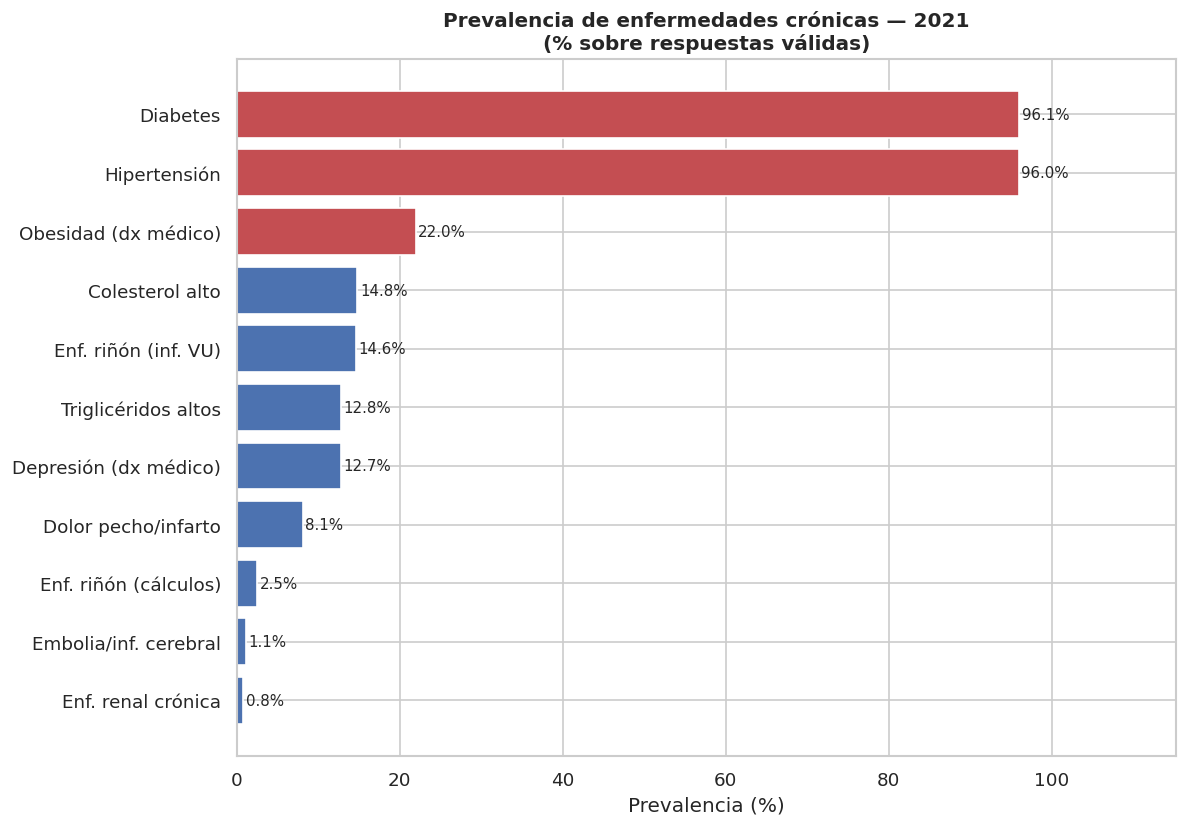

In [34]:
# Para 2021: Sí=1, No=3 en enfermedades diagnosticadas
# (columnas a0601a/b/c y otras siguen con 1=Sí, 2=No)
prev = {}
for label, col in enf_cols.items():
    col_vals = df[col]
    # Detectar codificación: si hay valor 3 pero no 2 → No=3
    has_3 = (col_vals == 3).sum() > 0
    has_2 = (col_vals == 2).sum() > 0
    if has_3 and not has_2:
        valid = col_vals.isin([1, 3]).sum()
        si = (col_vals == 1).sum()
    else:
        valid = col_vals.isin([1, 2]).sum()
        si = (col_vals == 1).sum()
    prev[label] = si / valid * 100 if valid > 0 else 0

prev_series = pd.Series(prev).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10,7))
colors = ['#C44E52' if v > 15 else '#4C72B0' for v in prev_series.values]
bars = ax.barh(prev_series.index, prev_series.values, color=colors, edgecolor='white')
ax.set_title('Prevalencia de enfermedades crónicas — 2021\n(% sobre respuestas válidas)', fontweight='bold')
ax.set_xlabel('Prevalencia (%)')
for bar, val in zip(bars, prev_series.values):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, prev_series.max()*1.2)
plt.tight_layout()
plt.savefig('../outputs/figures/2021/eda_enfermedades.png', bbox_inches='tight')
plt.show()

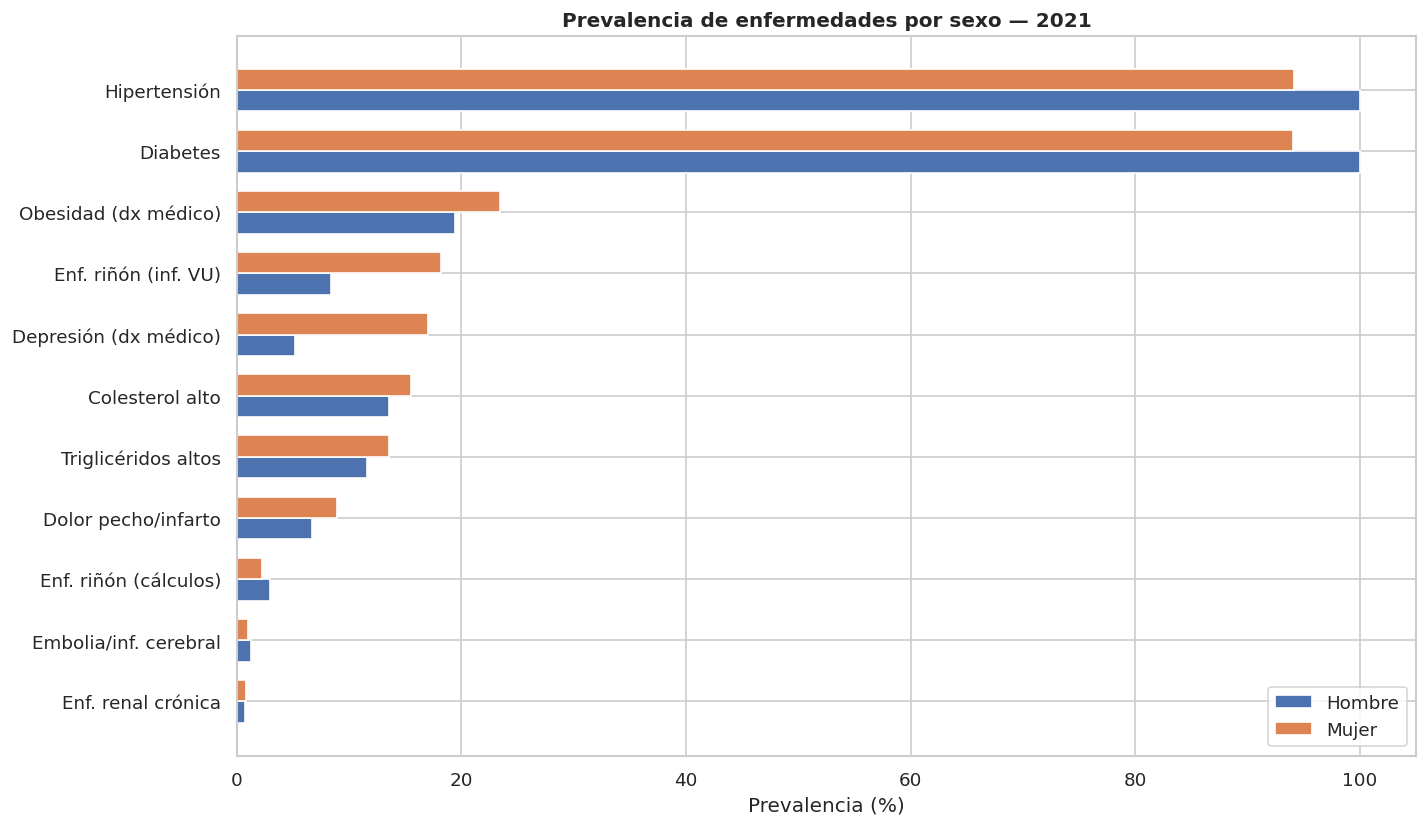

In [35]:
# Prevalencia por sexo
fig, ax = plt.subplots(figsize=(12,7))
enf_sexo = []
for label, col in enf_cols.items():
    col_vals = df[col]
    has_3 = (col_vals == 3).sum() > 0
    has_2 = (col_vals == 2).sum() > 0
    no_val = 3 if (has_3 and not has_2) else 2
    for sexo in ['Hombre','Mujer']:
        sub = df[df['Sexo']==sexo][col]
        valid = sub.isin([1, no_val]).sum()
        si = (sub == 1).sum()
        enf_sexo.append({'Enfermedad':label,'Sexo':sexo,'Prevalencia (%)': si/valid*100 if valid>0 else 0})

enf_sexo_df = pd.DataFrame(enf_sexo)
pivot = enf_sexo_df.pivot(index='Enfermedad', columns='Sexo', values='Prevalencia (%)').sort_values('Mujer')
x = np.arange(len(pivot)); w = 0.35
ax.barh(x-w/2, pivot['Hombre'], w, label='Hombre', color='#4C72B0', edgecolor='white')
ax.barh(x+w/2, pivot['Mujer'],  w, label='Mujer',  color='#DD8452', edgecolor='white')
ax.set_yticks(x); ax.set_yticklabels(pivot.index)
ax.set_xlabel('Prevalencia (%)'); ax.set_title('Prevalencia de enfermedades por sexo — 2021', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/2021/eda_enf_sexo.png', bbox_inches='tight')
plt.show()

### 3.3 Salud mental

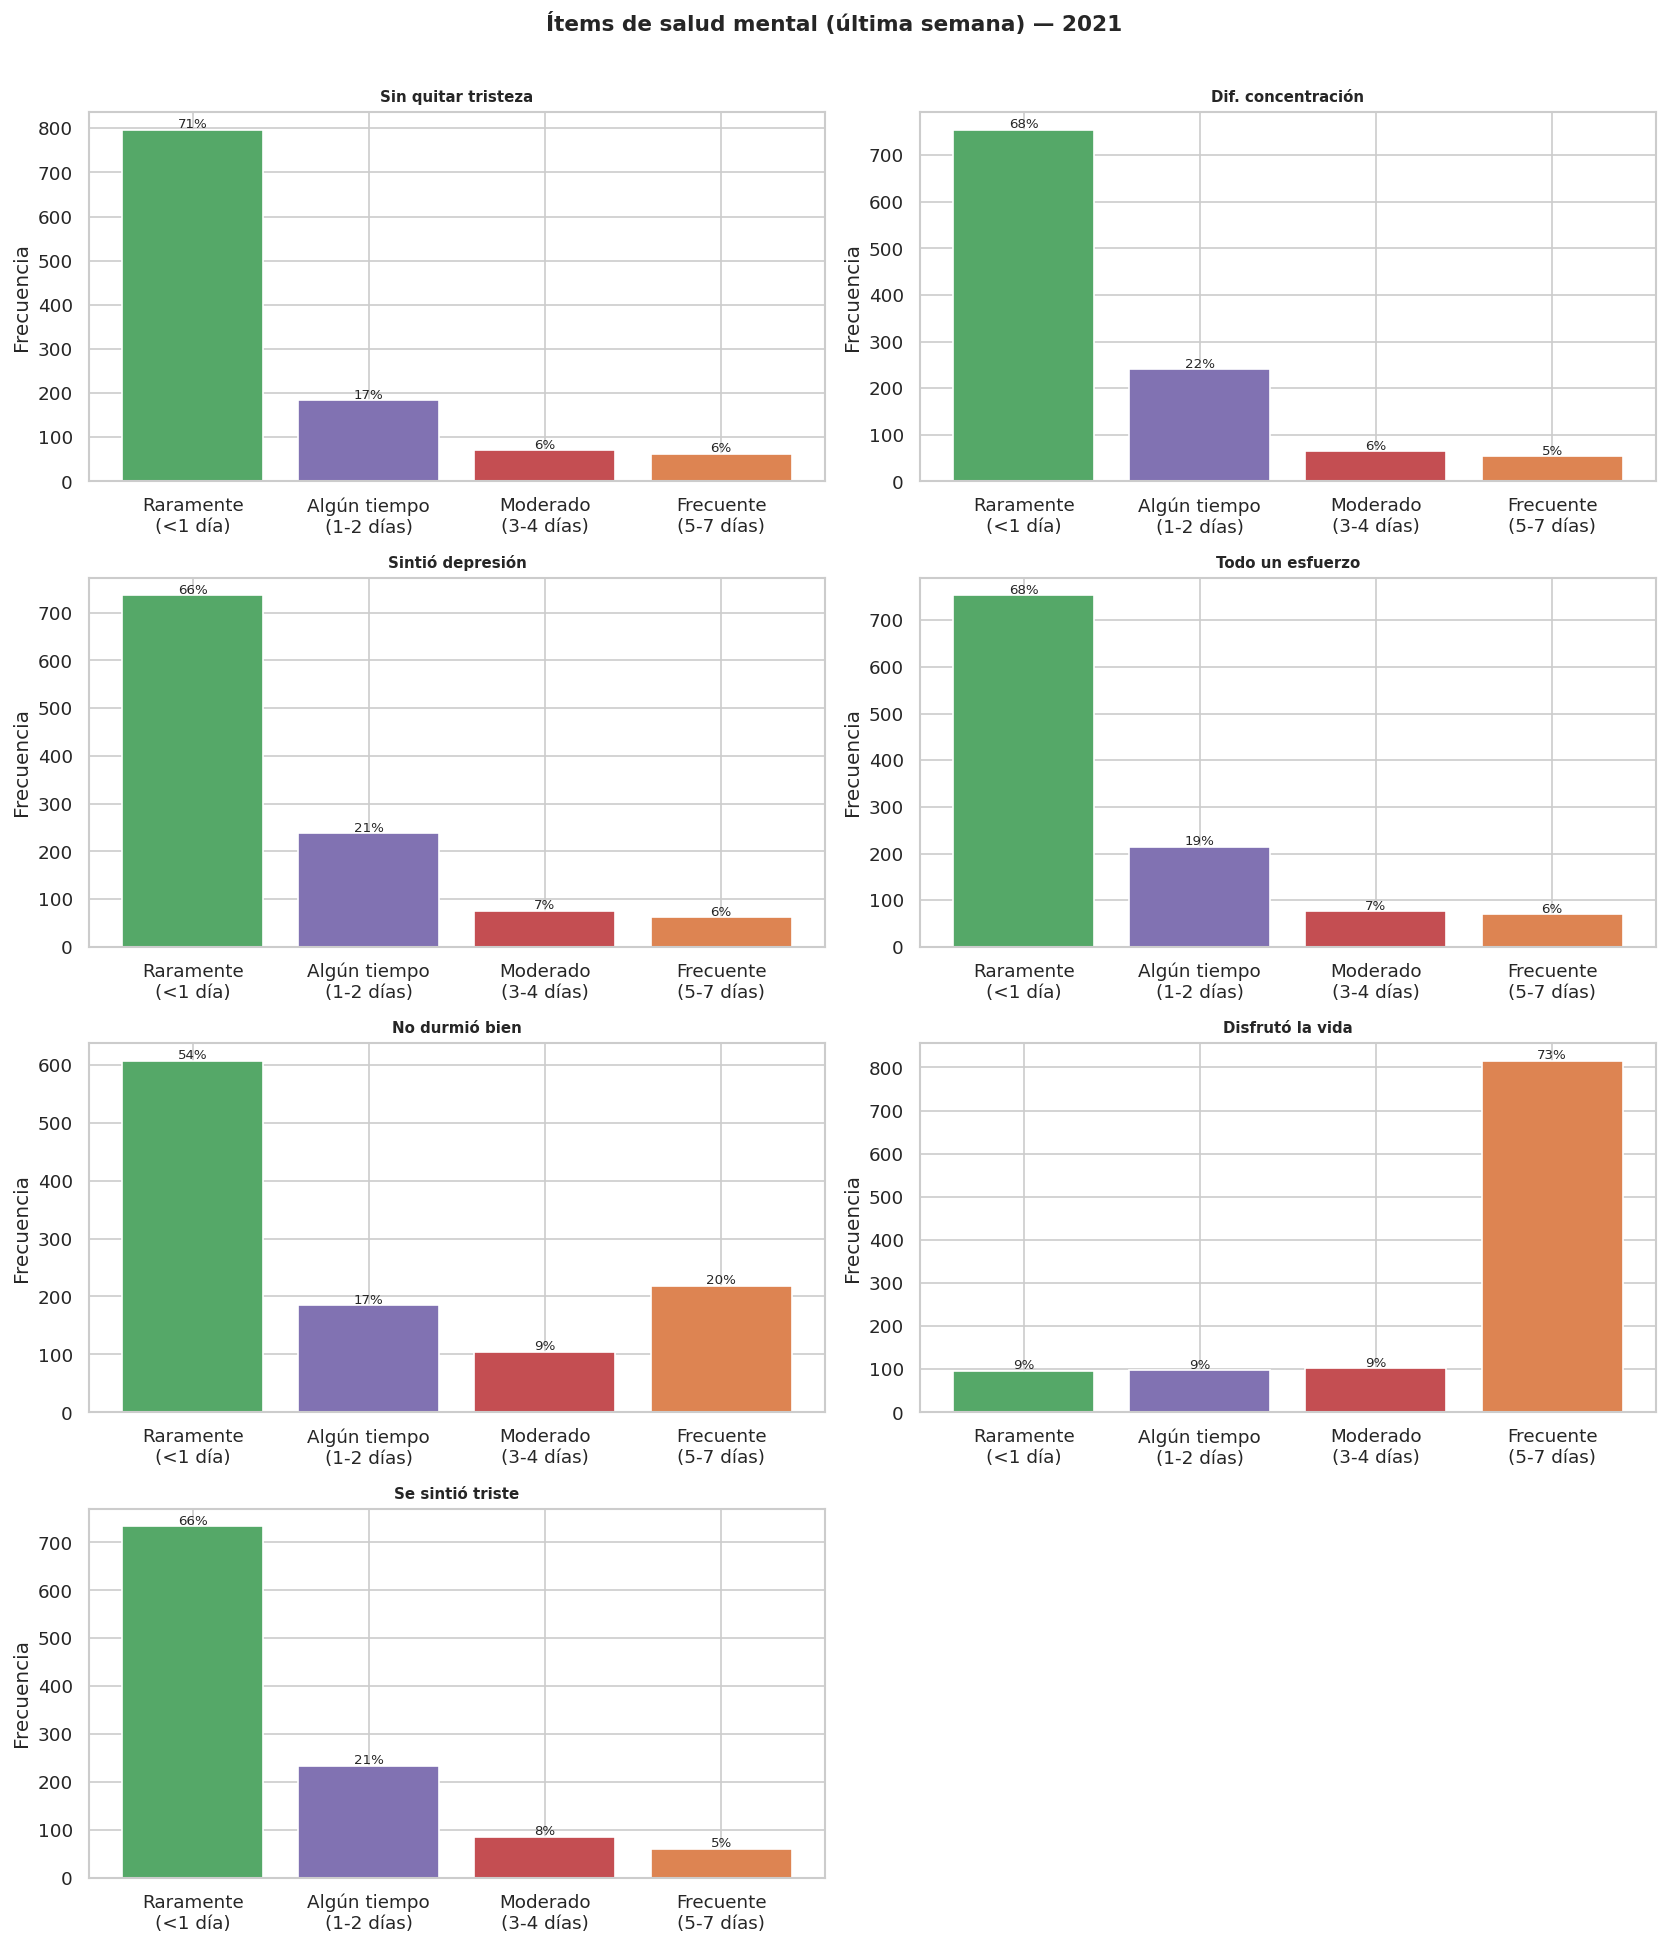

In [36]:
dep_items = {
    'Sin quitar tristeza':   'Durante la última semana...¿Sentía como si no pudiera quitarse de encima la tris',
    'Dif. concentración':    'Durante la última semana...¿le costaba concentrarse en lo que estaba haciendo?',
    'Sintió depresión':      'Durante la última semana...¿se sintió deprimido/a?',
    'Todo un esfuerzo':      'Durante la última semana...¿le parecía que todo lo que hacía era un esfuerzo?',
    'No durmió bien':        'Durante la última semana...¿no durmió bien?',
    'Disfrutó la vida':      'Durante la última semana...¿disfruto de la vida?',
    'Se sintió triste':      'Durante la última semana...¿se sintió triste?',
}
dep_items = {k:v for k,v in dep_items.items() if v in df.columns}
labels_resp = {1:'Raramente\n(<1 día)',2:'Algún tiempo\n(1-2 días)',3:'Moderado\n(3-4 días)',4:'Frecuente\n(5-7 días)'}
colors_dep = ['#55A868','#8172B2','#C44E52','#DD8452']

fig, axes = plt.subplots(4, 2, figsize=(14,16))
axes = axes.flatten()
for idx, (label, col) in enumerate(dep_items.items()):
    ax = axes[idx]
    counts = df[col].value_counts().sort_index()
    counts.index = [labels_resp.get(i, str(i)) for i in counts.index]
    ax.bar(counts.index, counts.values, color=colors_dep, edgecolor='white')
    ax.set_title(label, fontsize=9, fontweight='bold'); ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for i, (xi, v) in enumerate(zip(counts.index, counts.values)):
        ax.text(i, v+3, f'{v/total*100:.0f}%', ha='center', fontsize=8)
for idx in range(len(dep_items), len(axes)):
    axes[idx].set_visible(False)
fig.suptitle('Ítems de salud mental (última semana) — 2021', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/2021/eda_salud_mental_items.png', bbox_inches='tight')
plt.show()

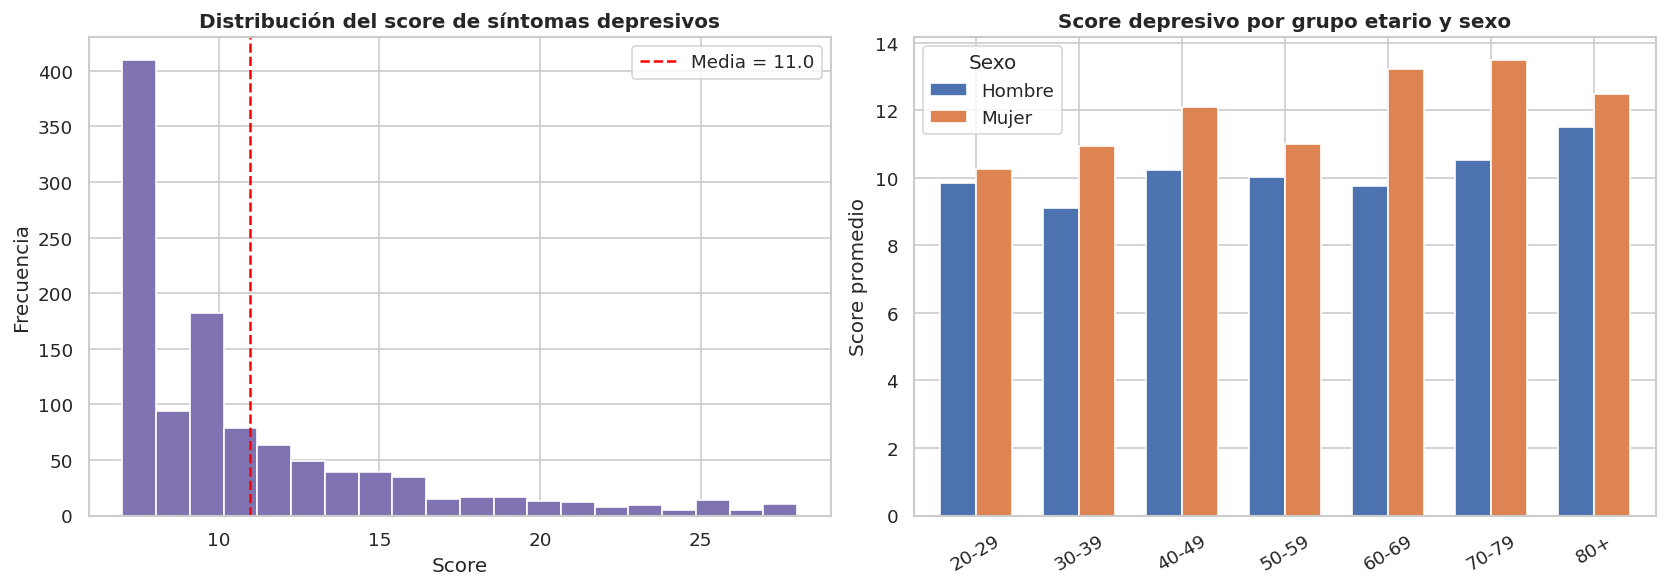

In [37]:
if 'Score depresión' in df.columns:
    fig, axes = plt.subplots(1,2, figsize=(14,5))
    ax = axes[0]
    ax.hist(df['Score depresión'].dropna(), bins=20, color='#8172B2', edgecolor='white')
    ax.set_title('Distribución del score de síntomas depresivos', fontweight='bold')
    ax.set_xlabel('Score'); ax.set_ylabel('Frecuencia')
    ax.axvline(df['Score depresión'].mean(), color='red', linestyle='--',
               label=f'Media = {df["Score depresión"].mean():.1f}')
    ax.legend()

    ax = axes[1]
    pivot_dep = df.groupby(['Grupo etario','Sexo'], observed=True)['Score depresión'].mean().unstack()
    pivot_dep.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'], edgecolor='white', width=0.7)
    ax.set_title('Score depresivo por grupo etario y sexo', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('Score promedio'); ax.legend(title='Sexo')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig('../outputs/figures/2021/eda_score_depresion.png', bbox_inches='tight')
    plt.show()

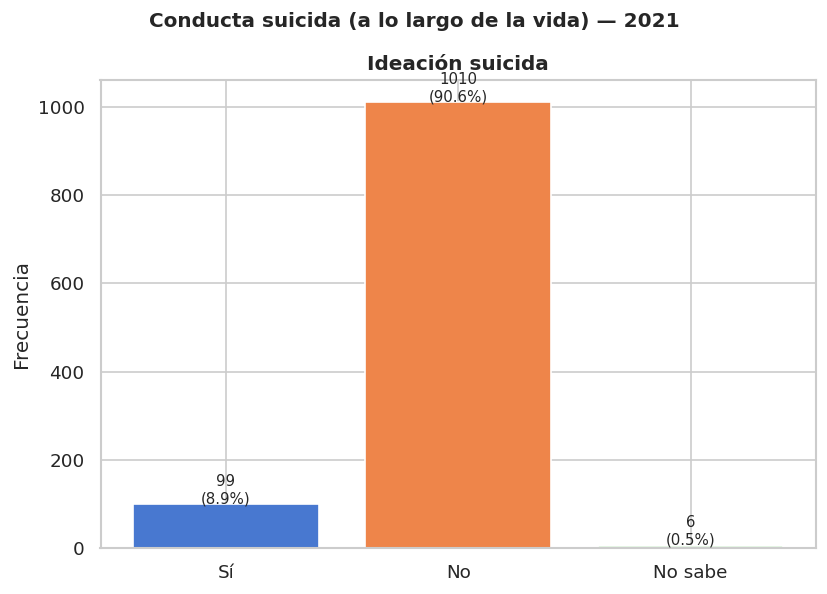

In [38]:
suicide_cols = {
    'Ideación suicida': 'A1211 ¿Alguna vez ha pensado en suicidarse?',
    'Intento suicida':  'A1213 ¿Alguna vez a propósito se ha herido, cortado, intoxicado o hecho daño con el fin de quitarse la vida?',
}
suicide_cols = {k:v for k,v in suicide_cols.items() if v in df.columns}
if suicide_cols:
    fig, axes = plt.subplots(1, len(suicide_cols), figsize=(7*len(suicide_cols), 5))
    if len(suicide_cols)==1: axes=[axes]
    for ax,(label,col) in zip(axes, suicide_cols.items()):
        counts = df[col].value_counts().sort_index()
        lmap = {1:'Sí',2:'No',3:'No aplica',9:'No sabe'}
        counts.index = [lmap.get(i, str(i)) for i in counts.index]
        pcts = counts/counts.sum()*100
        bars = ax.bar(counts.index, counts.values,
                      color=sns.color_palette('muted', len(counts)), edgecolor='white')
        ax.set_title(label, fontweight='bold'); ax.set_ylabel('Frecuencia')
        for bar,val,pct in zip(bars,counts.values,pcts.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                    f'{val}\n({pct:.1f}%)', ha='center', fontsize=9)
    plt.suptitle('Conducta suicida (a lo largo de la vida) — 2021', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/figures/2021/eda_suicidio.png', bbox_inches='tight')
    plt.show()

### 3.4 Estilos de vida

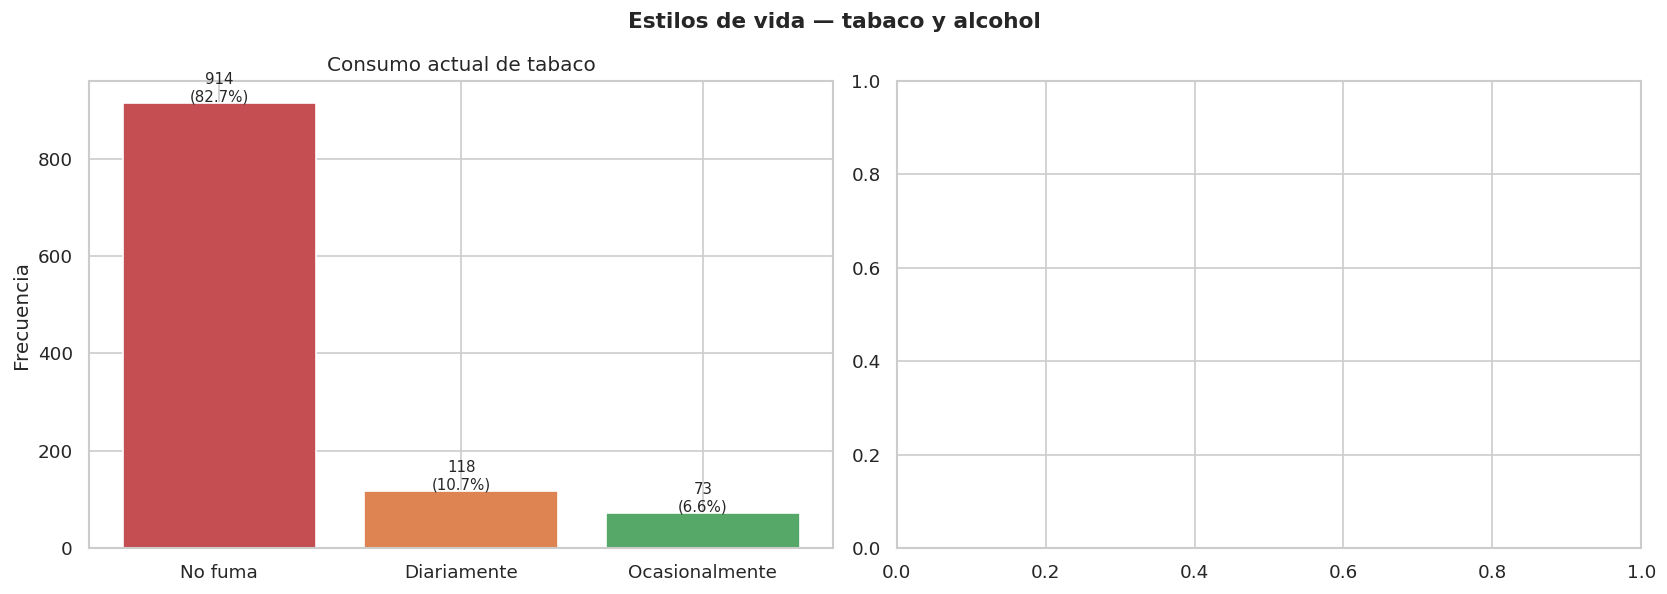

In [39]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
fig.suptitle('Estilos de vida — tabaco y alcohol', fontsize=13, fontweight='bold')

col_tab = 'A1301 Actualmente, ¿fuma tabaco…'
if col_tab in df.columns:
    ax = axes[0]
    tab_map = {1:'Diariamente',2:'Ocasionalmente',3:'No fuma'}
    counts = df[col_tab].map(tab_map).value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=['#C44E52','#DD8452','#55A868'], edgecolor='white')
    ax.set_title('Consumo actual de tabaco'); ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for bar,val in zip(bars,counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=9)

col_alc = 'A1308 En los últimos 12 meses,¿Con qué frecuencia tomó al menos una copa ya sea de vino, cerveza, whisky o cualquier otra bebida que contenga alcohol?'
if col_alc in df.columns:
    ax = axes[1]
    alc_map = {1:'Diario',2:'Semanal',3:'Mensual',4:'Anual',5:'Nunca',6:'Dejó'}
    counts = df[col_alc].map(alc_map).value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('muted', len(counts)), edgecolor='white')
    ax.set_title('Frecuencia de consumo de alcohol (12 meses)'); ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for bar,val in zip(bars,counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/2021/eda_estilos_vida.png', bbox_inches='tight')
plt.show()

### 3.5 Actividad física (nuevo en 2021)

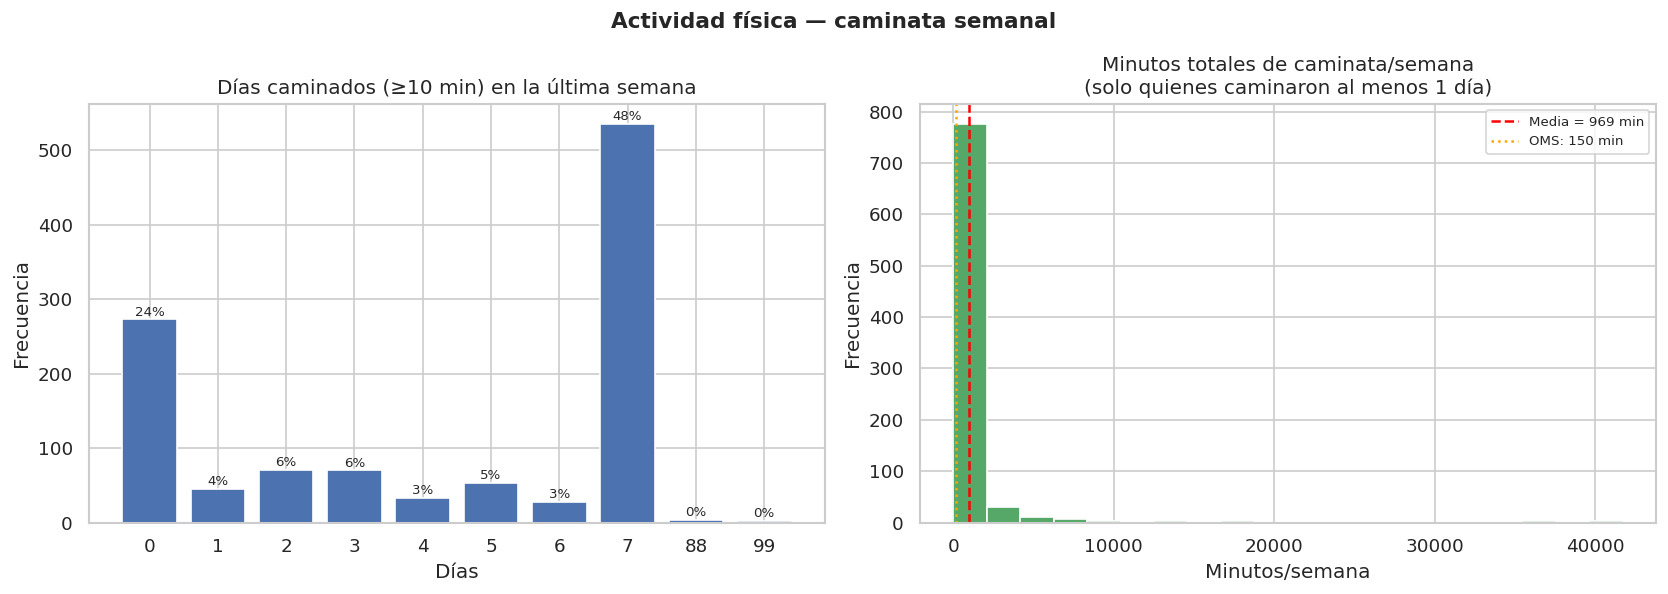

% que cumple recomendación OMS (≥150 min/sem): 41.6%


In [40]:
col_dias  = 'A1409 Durante los últimos 7 días, ¿Cuántos días usted caminó por lo menos 10 min'
col_mints = 'Minutos caminata/semana'

if col_dias in df.columns:
    fig, axes = plt.subplots(1,2, figsize=(14,5))
    fig.suptitle('Actividad física — caminata semanal', fontsize=13, fontweight='bold')

    ax = axes[0]
    counts = df[col_dias].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color='#4C72B0', edgecolor='white')
    ax.set_title('Días caminados (≥10 min) en la última semana')
    ax.set_xlabel('Días'); ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for i,(xi,v) in enumerate(zip(counts.index,counts.values)):
        ax.text(i, v+5, f'{v/total*100:.0f}%', ha='center', fontsize=8)

    if col_mints in df.columns:
        ax = axes[1]
        walkers = df[df[col_dias]>0][col_mints]
        ax.hist(walkers, bins=20, color='#55A868', edgecolor='white')
        ax.set_title('Minutos totales de caminata/semana\n(solo quienes caminaron al menos 1 día)')
        ax.set_xlabel('Minutos/semana'); ax.set_ylabel('Frecuencia')
        ax.axvline(walkers.mean(), color='red', linestyle='--',
                   label=f'Media = {walkers.mean():.0f} min')
        ax.axvline(150, color='orange', linestyle=':', label='OMS: 150 min')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('../outputs/figures/2021/eda_actividad_fisica.png', bbox_inches='tight')
    plt.show()

    cumple_oms = (df[col_mints] >= 150).mean()*100 if col_mints in df.columns else None
    print(f'% que cumple recomendación OMS (≥150 min/sem): {cumple_oms:.1f}%' if cumple_oms else '')

### 3.6 Antecedentes familiares de enfermedades

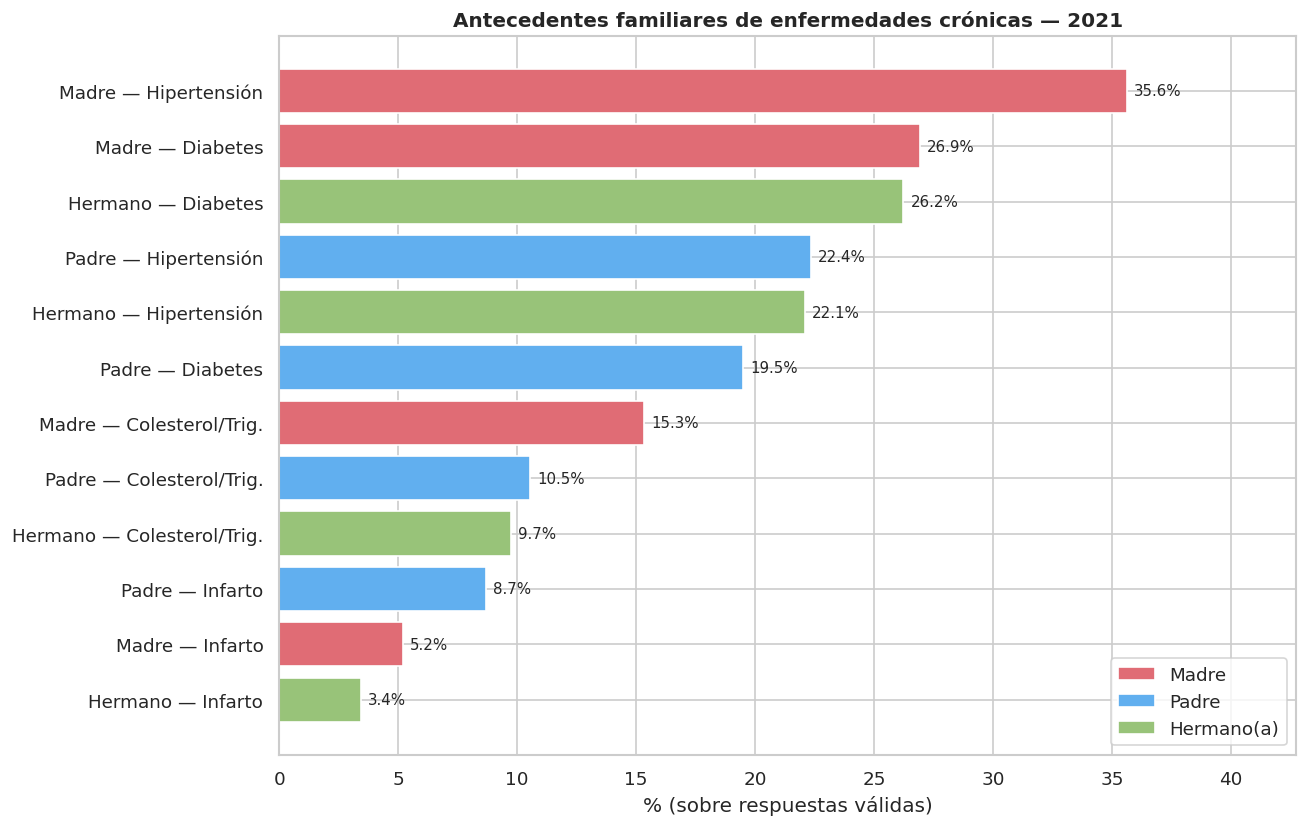

In [41]:
antec_map = {
    'Padre — Diabetes':         '¿Su PADRE tiene o tuvo diabetes o azúcar alta en la sangre?',
    'Padre — Hipertensión':     '¿Su PADRE tiene o tuvo hipertensión o presión alta?',
    'Padre — Infarto':          '¿Su PADRE  tuvo un infarto?',
    'Padre — Colesterol/Trig.': '¿Su PADRE tuvo valores altos de colesterol y/o triglicéridos?',
    'Madre — Diabetes':         '¿Su MADRE tiene o tuvo diabetes o azúcar alta en la sangre?',
    'Madre — Hipertensión':     '¿Su MADRE tiene o tuvo hipertensión o presión alta?',
    'Madre — Infarto':          '¿Su MADRE  tuvo un infarto?',
    'Madre — Colesterol/Trig.': '¿Su MADRE tuvo valores altos de colesterol y/o triglicéridos?',
    'Hermano — Diabetes':       '¿Su HERMANO(A) tiene o tuvo diabetes o azúcar alta en la sangre?',
    'Hermano — Hipertensión':   '¿Su HERMANO(A) tiene o tuvo hipertensión o presión alta?',
    'Hermano — Infarto':        '¿Su HERMANO(A)  tuvo un infarto?',
    'Hermano — Colesterol/Trig.':'¿Su HERMANO(A) tuvo valores altos de colesterol y/o triglicéridos?',
}
antec_map = {k:v for k,v in antec_map.items() if v in df.columns}

antec_pct = {}
for label, col in antec_map.items():
    valid = df[col].isin([1,2])
    antec_pct[label] = (df.loc[valid, col]==1).mean()*100

antec_s = pd.Series(antec_pct).sort_values(ascending=True)
colors = ['#E06C75' if 'Madre' in k else '#61AFEF' if 'Padre' in k else '#98C379' for k in antec_s.index]

fig, ax = plt.subplots(figsize=(11,7))
bars = ax.barh(antec_s.index, antec_s.values, color=colors, edgecolor='white')
ax.set_title('Antecedentes familiares de enfermedades crónicas — 2021', fontweight='bold')
ax.set_xlabel('% (sobre respuestas válidas)')
for bar, val in zip(bars, antec_s.values):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, antec_s.max()*1.2)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#E06C75',label='Madre'),
                   Patch(facecolor='#61AFEF',label='Padre'),
                   Patch(facecolor='#98C379',label='Hermano(a)')], loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/2021/eda_antecedentes_familiares.png', bbox_inches='tight')
plt.show()

### 3.7 Discapacidades y dificultades funcionales

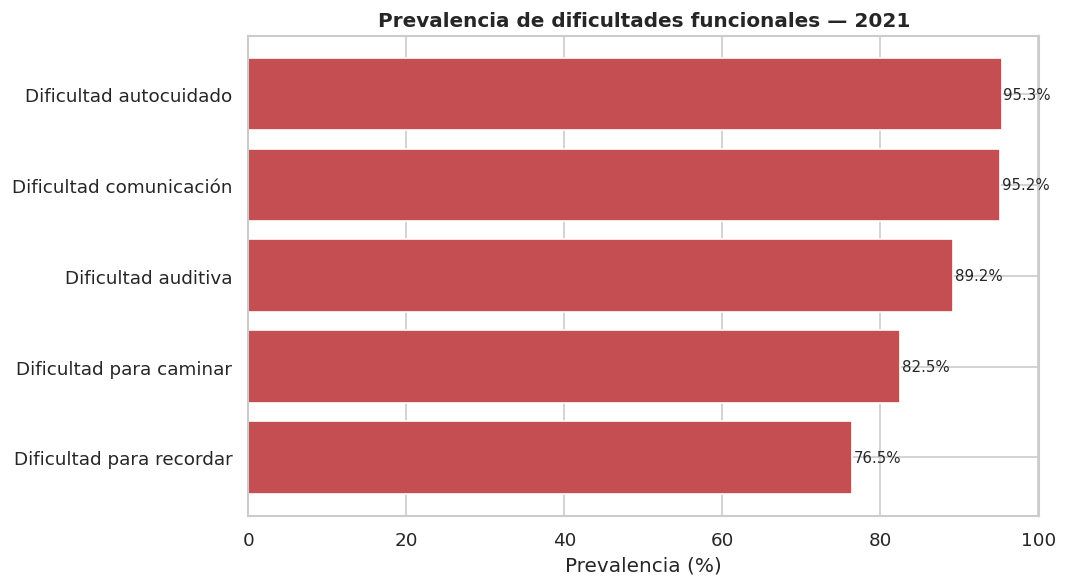

In [42]:
dif_cols = {
    'Dificultad auditiva':     'A1404B ¿Tiene dificultades para oír?',
    'Dificultad para caminar': 'A1405 ¿Tiene dificultad para caminar o subir escalones?',
    'Dificultad para recordar':'A1406 ¿Tiene dificultad para recordar o concentrarse?',
    'Dificultad autocuidado':  'A1407 ¿Tiene dificultad para el cuidado propio, tal como lavarse todo el cuerpo',
    'Dificultad comunicación': 'A1408 Usando su idioma habitual, ¿tiene dificultad para comunicarse, por ejemplo',
}
dif_cols = {k:v for k,v in dif_cols.items() if v in df.columns}
dif_pct = {}
for label, col in dif_cols.items():
    valid = df[col].isin([1,2,3])
    dif_pct[label] = (df.loc[valid, col].isin([1,3])).mean()*100
dif_s = pd.Series(dif_pct).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.barh(dif_s.index, dif_s.values, color='#C44E52', edgecolor='white')
ax.set_title('Prevalencia de dificultades funcionales — 2021', fontweight='bold')
ax.set_xlabel('Prevalencia (%)')
for bar, val in zip(bars, dif_s.values):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/2021/eda_discapacidades.png', bbox_inches='tight')
plt.show()

### 3.8 Percepción corporal y peso

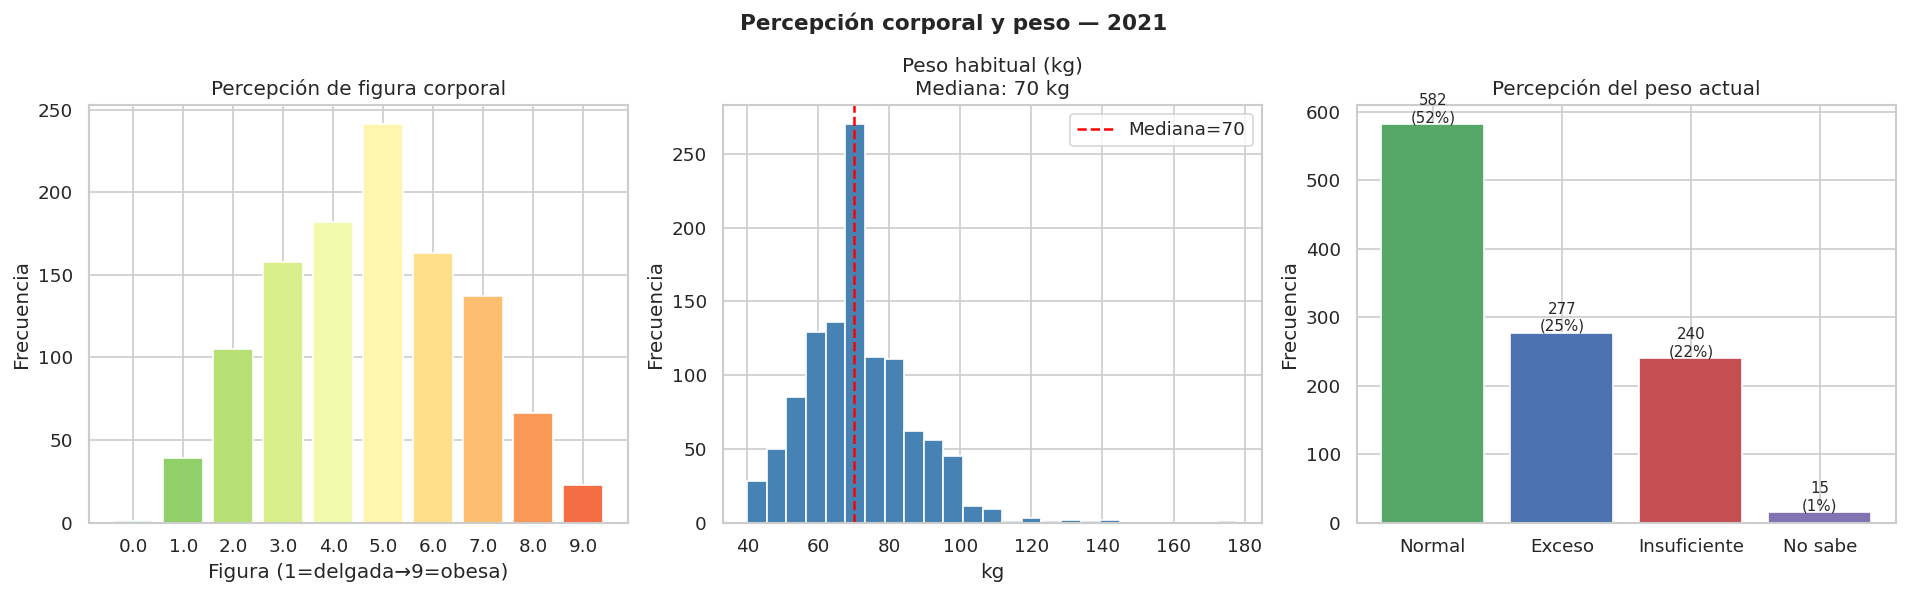

In [43]:
fig, axes = plt.subplots(1,3, figsize=(16,5))
fig.suptitle('Percepción corporal y peso — 2021', fontsize=13, fontweight='bold')

col_fig = 'Ahora le voy a mostrar unas figuras corporales, por favor, dígame qué figura sie'
if col_fig in df.columns:
    ax = axes[0]
    counts = df[col_fig].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color=plt.cm.RdYlGn_r(np.linspace(0.2,0.8,len(counts))), edgecolor='white')
    ax.set_title('Percepción de figura corporal'); ax.set_xlabel('Figura (1=delgada→9=obesa)'); ax.set_ylabel('Frecuencia')

col_peso_h = '¿Cuál es su peso habitual sin ropa y zapatos?'
if col_peso_h in df.columns:
    ax = axes[1]
    vals = df[col_peso_h].dropna()
    ax.hist(vals, bins=25, color='steelblue', edgecolor='white')
    ax.set_title(f'Peso habitual (kg)\nMediana: {vals.median():.0f} kg'); ax.set_xlabel('kg'); ax.set_ylabel('Frecuencia')
    ax.axvline(vals.median(), color='red', linestyle='--', label=f'Mediana={vals.median():.0f}')
    ax.legend()

col_percep = '¿Considera que su peso actual es...'
if col_percep in df.columns:
    ax = axes[2]
    peso_map = {1:'Insuficiente',2:'Normal',3:'Exceso',9:'No sabe'}
    counts = df[col_percep].map(peso_map).value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=['#55A868','#4C72B0','#C44E52','#8172B2'], edgecolor='white')
    ax.set_title('Percepción del peso actual'); ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for bar,val in zip(bars,counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                f'{val}\n({val/total*100:.0f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/2021/eda_peso_corporal.png', bbox_inches='tight')
plt.show()

### 3.9 Mapa de correlaciones

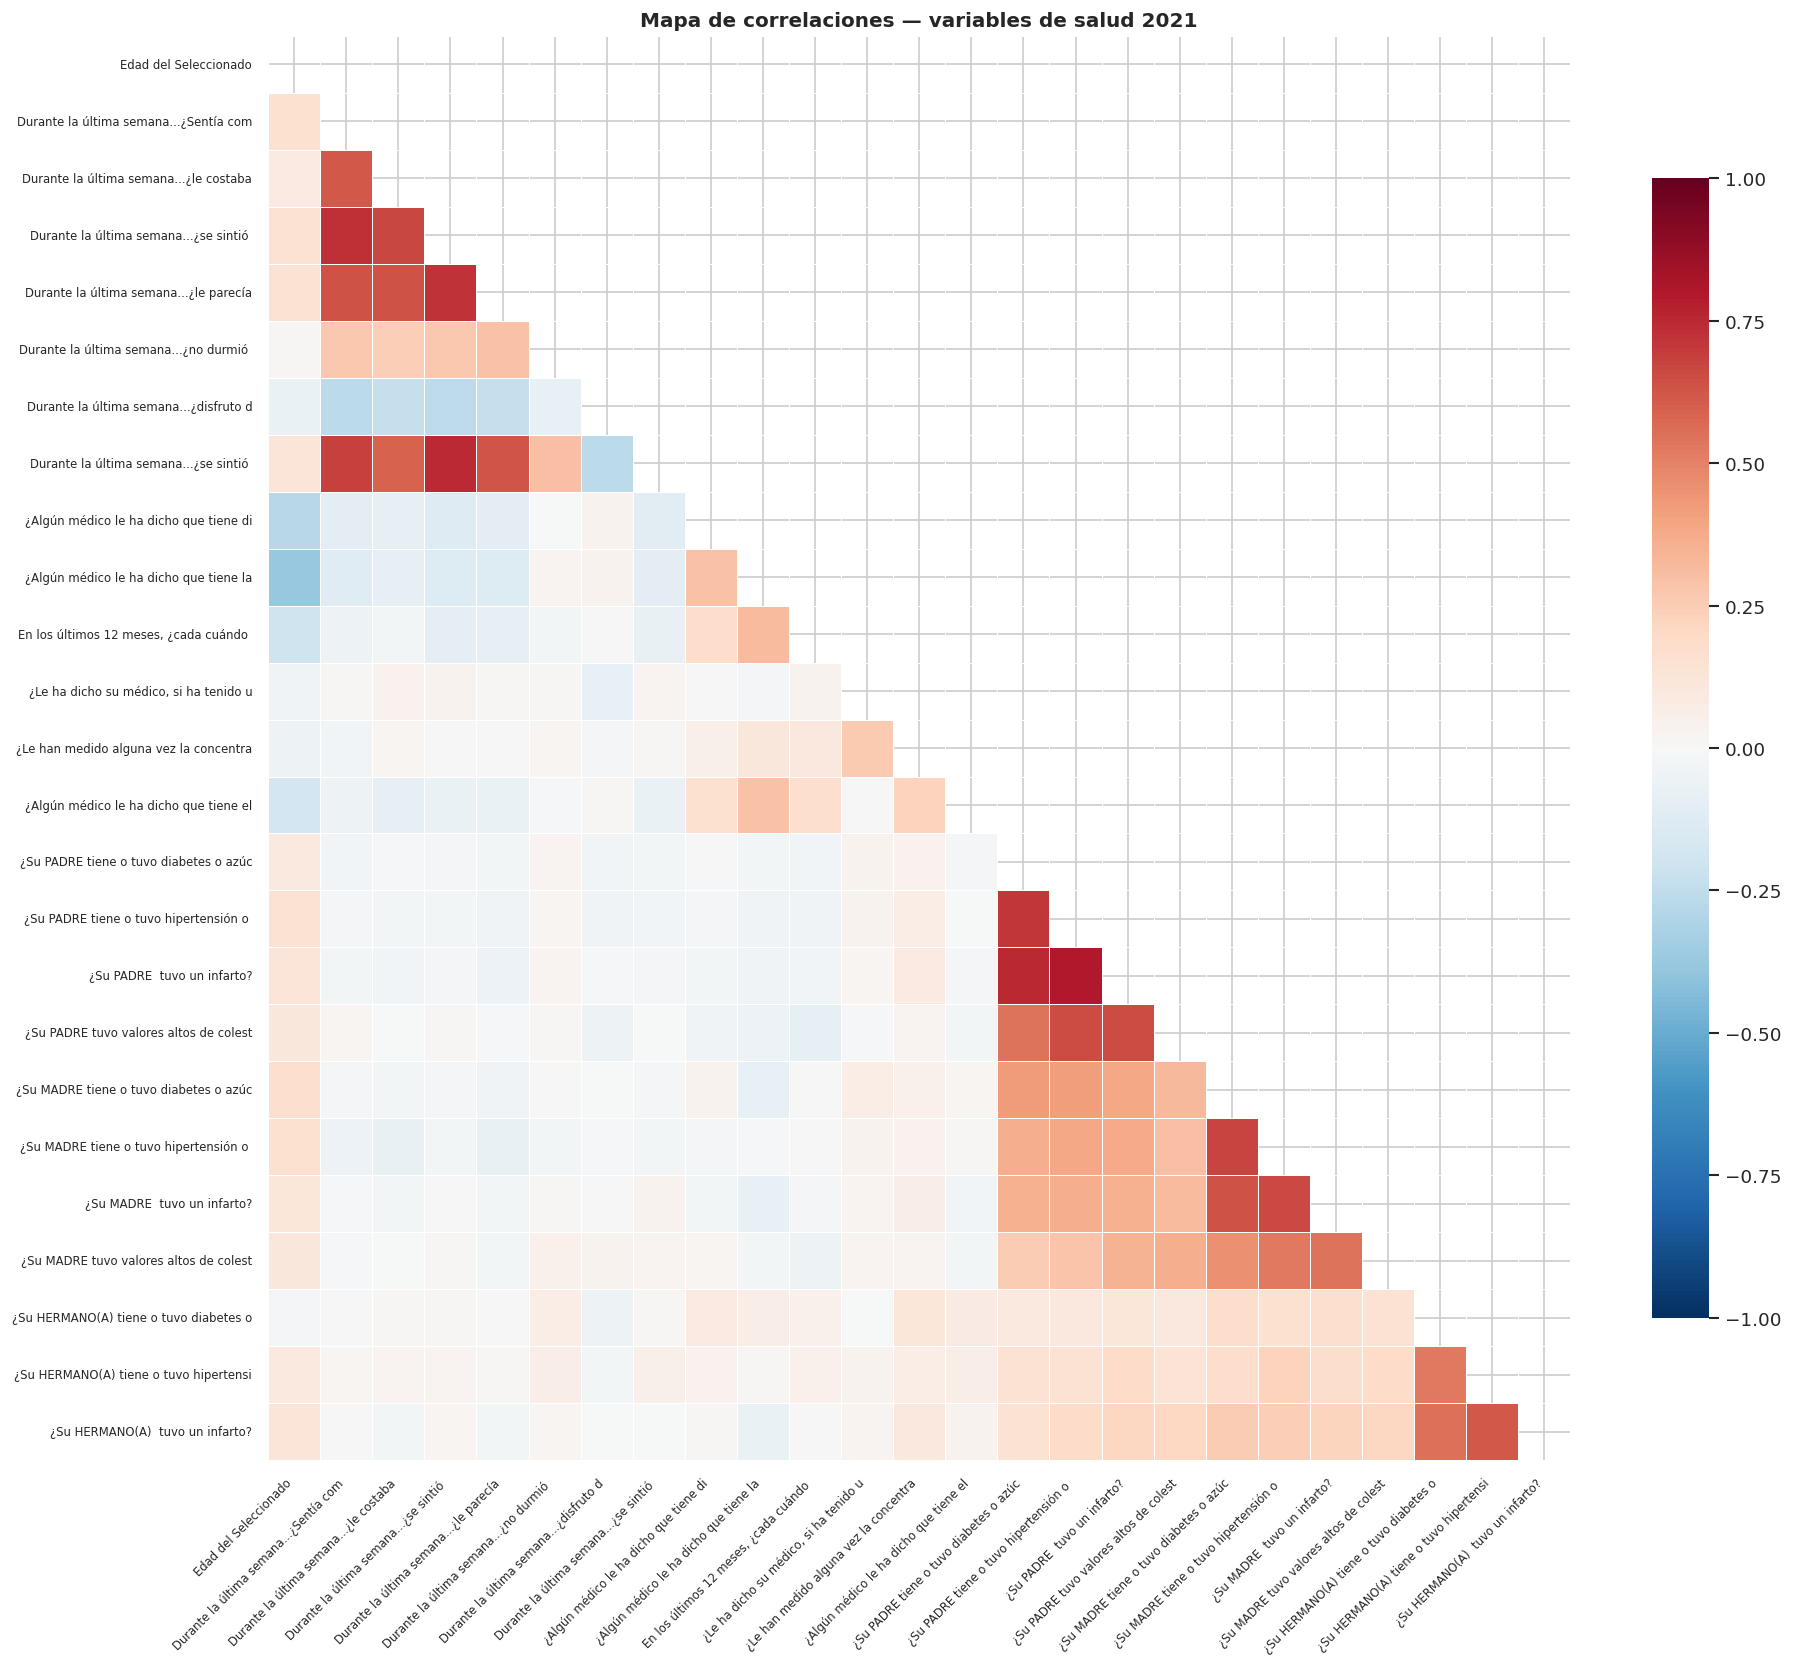

In [44]:
health_num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                   if c not in ['Municipio','Estrato de seleccion','Ponderador',
                                'Estrato urbanidad/ruralidad','Sexo del Seleccionado']]
if len(health_num_cols) > 25:
    priority = [c for c in health_num_cols if any(
        k in str(c) for k in ['diabetes','presión','Diabetes','Presión','colesterol',
                               'infarto','semana','Score','Edad','tabaco','Minutos',
                               'caminata','renal','Triglicéridos','Depresión'])]
    health_num_cols = (priority + [c for c in health_num_cols if c not in priority])[:25]

corr_df = df[health_num_cols].copy()
short = {c: c[:38] for c in corr_df.columns}
corr_df.rename(columns=short, inplace=True)

fig, ax = plt.subplots(figsize=(16,14))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=False, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3, cbar_kws={'shrink':0.8})
ax.set_title('Mapa de correlaciones — variables de salud 2021', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('../outputs/figures/2021/eda_correlaciones.png', bbox_inches='tight')
plt.show()

---
## 4. Resumen ejecutivo

In [45]:
print('=' * 60)
print('RESUMEN — ENSADUL 2021 Guanajuato')
print('=' * 60)
print(f'  Total de encuestados:    {len(df):,}')
print(f'  Variables de análisis:   {len(df.columns)}')
print(f'  Edad promedio:           {df["Edad del Seleccionado"].mean():.1f} años')
print(f'  Mujeres: {(df["Sexo"]=="Mujer").sum():,} ({(df["Sexo"]=="Mujer").mean()*100:.1f}%)')
print(f'  Hombres: {(df["Sexo"]=="Hombre").sum():,} ({(df["Sexo"]=="Hombre").mean()*100:.1f}%)')
print()
print('  Enfermedades crónicas (prevalencia):')
for label, val in list(prev_series.sort_values(ascending=False).items())[:5]:
    print(f'    {label:<35} {val:.1f}%')
print()
if 'Score depresión' in df.columns:
    print(f'  Score depresión promedio: {df["Score depresión"].mean():.1f}')
if 'Minutos caminata/semana' in df.columns:
    print(f'  % cumple OMS (≥150 min/sem): {(df["Minutos caminata/semana"]>=150).mean()*100:.1f}%')
print('=' * 60)

RESUMEN — ENSADUL 2021 Guanajuato
  Total de encuestados:    1,115
  Variables de análisis:   79
  Edad promedio:           46.2 años
  Mujeres: 709 (63.6%)
  Hombres: 406 (36.4%)

  Enfermedades crónicas (prevalencia):
    Diabetes                            96.1%
    Hipertensión                        96.0%
    Obesidad (dx médico)                22.0%
    Colesterol alto                     14.8%
    Enf. riñón (inf. VU)                14.6%

  Score depresión promedio: 11.0
  % cumple OMS (≥150 min/sem): 41.6%
